In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
import pandas as pd

In [2]:
# read wild type sequence
wt_seq = []
with open("PDZ3_wt.fasta",'r') as fasta_in:
    for i, line in enumerate(fasta_in):
        if line.startswith(">"):
            wt_header = line.strip('\n')[1:]
        else:
            wt_seq.append(line.strip('\n'))
wt_seq = ''.join(wt_seq)
print(wt_header)
print(wt_seq)
print(len(wt_seq))

PDZ3_wt
LGEEDIPREPRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKPEEYSRFEANSRVDSSGRIVTD
114


In [4]:
# read seqs into dictionary
seqs = {}
with open("test_filter.fa",'r') as fasta_in:
    for i, line in enumerate(fasta_in):
        if line.startswith(">"):
            header = line.strip('\n')[1:]
            seqs[header] = []
        else:
            seqs[header].append(line.strip('\n'))
for header, seq in seqs.items():
    seqs[header] = ''.join(seq)
print(len(seqs))


549478


BIC by n_components: ['4909815', '4610830', '4598426']
Best n_components = 3


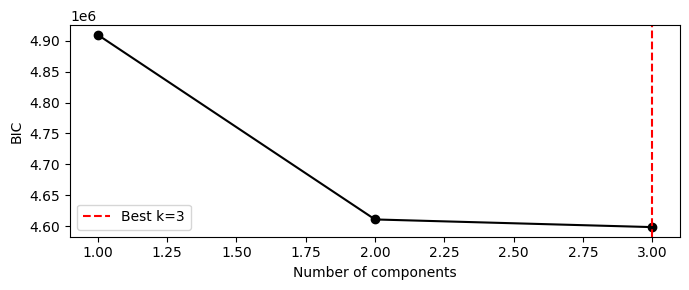


GMM components (mean ± std, weight):
  Component 0: mean=37.4, std=12.6, weight=0.1594
  Component 1: mean=80.3, std=12.8, weight=0.1986
  Component 2: mean=100.1, std=9.2, weight=0.6420

WT component: mean=100.10, std=9.20
Bounds (3σ): [72, 128]


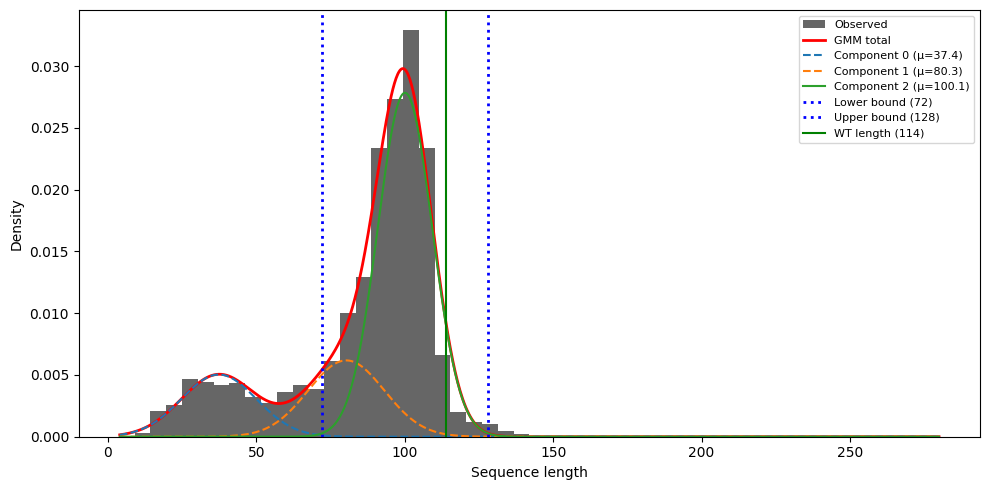


Filter: keep sequences with length in [72, 128]
Sequences retained: 429621 / 549478 (78.2%)


In [6]:
wt_len = 114
seq_lens_arr = np.array(seq_lens).reshape(-1, 1)

# --- BIC selection ---
max_components = 3
bics = []
for k in range(1, max_components + 1):
    gmm_k = GaussianMixture(n_components=k, random_state=42)
    gmm_k.fit(seq_lens_arr)
    bics.append(gmm_k.bic(seq_lens_arr))

best_k = np.argmin(bics) + 1
print(f"BIC by n_components: {[f'{b:.0f}' for b in bics]}")
print(f"Best n_components = {best_k}")

fig_bic, ax_bic = plt.subplots(figsize=(7, 3))
ax_bic.plot(range(1, max_components + 1), bics, 'ko-')
ax_bic.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax_bic.set_xlabel('Number of components')
ax_bic.set_ylabel('BIC')
ax_bic.legend()
plt.tight_layout()
plt.show()

# --- Fit GMM with best k ---
gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm.fit(seq_lens_arr)

order = np.argsort(gmm.means_.ravel())
means = gmm.means_.ravel()[order]
stds = np.sqrt(gmm.covariances_.ravel()[order])
weights = gmm.weights_[order]

print("\nGMM components (mean ± std, weight):")
for i, (m, s, w) in enumerate(zip(means, stds, weights)):
    print(f"  Component {i}: mean={m:.1f}, std={s:.1f}, weight={w:.4f}")

wt_component = np.argmin(np.abs(means - wt_len))
wt_mean = means[wt_component]
wt_std = stds[wt_component]
print(f"\nWT component: mean={wt_mean:.2f}, std={wt_std:.2f}")

n_sigma = 3
lower_bound = int(np.floor(wt_mean - n_sigma * wt_std))
upper_bound = int(np.ceil(wt_mean + n_sigma * wt_std))
print(f"Bounds ({n_sigma}σ): [{lower_bound}, {upper_bound}]")

# --- Plot histogram with GMM overlay ---
x = np.linspace(min(seq_lens) - 5, max(seq_lens) + 5, 1000).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(seq_lens, bins=50, color='k', density=True, alpha=0.6, label='Observed')

colors = plt.cm.tab10.colors
ax.plot(x, np.exp(gmm.score_samples(x)), 'r-', lw=2, label='GMM total')

for i, (m, s, w) in enumerate(zip(means, stds, weights)):
    component_pdf = w * (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x.ravel() - m) / s) ** 2)
    ls = '-' if i == wt_component else '--'
    ax.plot(x, component_pdf, ls=ls, color=colors[i % len(colors)],
            label=f'Component {i} (μ={m:.1f})')

ax.axvline(lower_bound, color='blue', linestyle=':', lw=2, label=f'Lower bound ({lower_bound})')
ax.axvline(upper_bound, color='blue', linestyle=':', lw=2, label=f'Upper bound ({upper_bound})')
ax.axvline(wt_len, color='green', linestyle='-', lw=1.5, label=f'WT length ({wt_len})')
ax.set_xlabel('Sequence length')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nFilter: keep sequences with length in [{lower_bound}, {upper_bound}]")
kept = {h: s for h, s in seqs.items() if lower_bound <= len(s) <= upper_bound}
print(f"Sequences retained: {len(kept)} / {len(seq_lens)} ({100*len(kept)/len(seq_lens):.1f}%)")


In [8]:
# Distance matrix
pidmat = pd.read_csv("jh_rep_sim_mat.csv", index_col=0)
pidmat = pidmat.to_numpy()
pidmat

array([[1.      , 0.416667, 0.348837, ..., 0.420455, 0.426829, 0.368932],
       [0.416667, 1.      , 0.404762, ..., 0.380952, 0.451219, 0.392857],
       [0.348837, 0.404762, 1.      , ..., 0.418605, 0.451219, 0.406977],
       ...,
       [0.420455, 0.380952, 0.418605, ..., 1.      , 0.365854, 0.431818],
       [0.426829, 0.451219, 0.451219, ..., 0.365854, 1.      , 0.365854],
       [0.368932, 0.392857, 0.406977, ..., 0.431818, 0.365854, 1.      ]],
      shape=(1000, 1000))

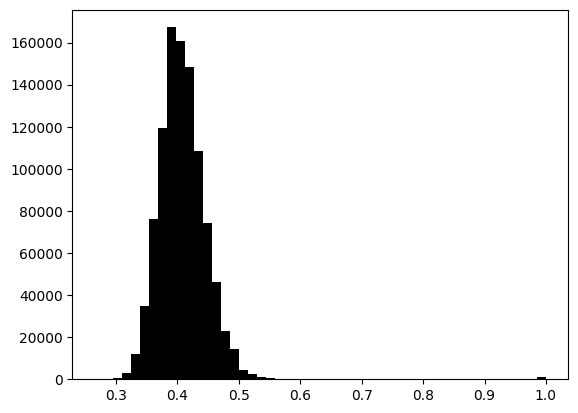

In [9]:
plt.hist(pidmat.flatten(), color='k', bins=50)
plt.show()

/tmp/ipykernel_473251/1168181352.py:23: RuntimeWarning: divide by zero encountered in log
  loo_ll[k] = np.nansum(np.log(row_sums / (n - 1))) - n * np.log(h)


Optimal bandwidth (LOO-CV): h = 0.5918


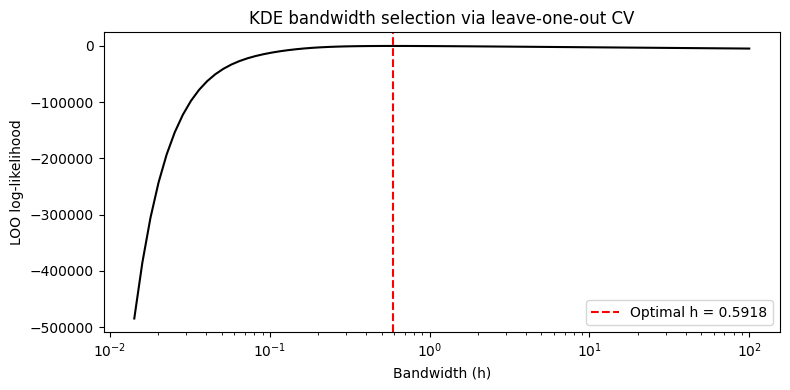

In [14]:

# LOO cross-validation to find optimal KDE bandwidth using precomputed PID matrix
# Distance metric: d_ij = 1 - PID_ij (so d in [0, 1], diagonal = 0)
# Gaussian kernel: K_h(d) = (1/h) * exp(-d^2 / (2*h^2))
# LOO log-likelihood: sum_i log( (1/(n-1)) * sum_{j!=i} (1/h)*K(d_ij/h) )
# The 1/h factor is critical: without it, LL -> 0 as h -> inf (no penalty for over-smoothing)

dist_mat = 1.0 - pidmat
n = dist_mat.shape[0]

# Precompute squared distances; set diagonal to NaN to exclude self
d_sq = dist_mat ** 2
np.fill_diagonal(d_sq, np.nan)

# Bandwidth grid: span the meaningful range of distances
bandwidths = np.logspace(-2, 2, 80)

loo_ll = np.zeros(len(bandwidths))
for k, h in enumerate(bandwidths):
    K = np.exp(-d_sq / (2 * h**2))
    row_sums = np.nansum(K, axis=1)           # sum over j != i
    row_sums = np.where(row_sums > 0, row_sums, np.nan)
    # -n*log(h) is the normalization penalty that prevents LL from trivially -> 0
    loo_ll[k] = np.nansum(np.log(row_sums / (n - 1))) - n * np.log(h)

best_idx = np.nanargmax(loo_ll)
best_h = bandwidths[best_idx]
print(f"Optimal bandwidth (LOO-CV): h = {best_h:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(bandwidths, loo_ll, 'k-', lw=1.5)
ax.axvline(best_h, color='red', linestyle='--', label=f'Optimal h = {best_h:.4f}')
ax.set_xlabel('Bandwidth (h)')
ax.set_ylabel('LOO log-likelihood')
ax.set_title('KDE bandwidth selection via leave-one-out CV')
ax.legend()
plt.tight_layout()
plt.show()


Weights: min=9.1458e-01, max=1.0944e+00, effective N = 999.4 (of 1000)


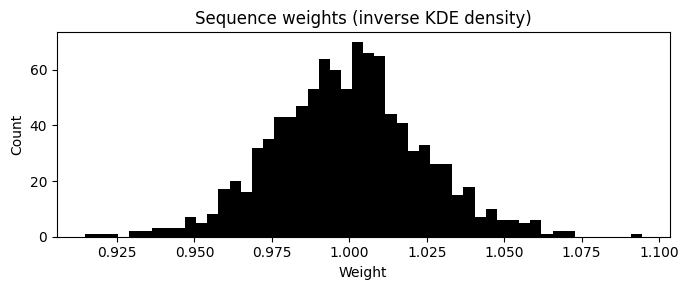

In [16]:

# Compute sequence weights: w_i ∝ 1 / sum_j K(d_ij)
# Uses full kernel sum (including self, j=i where d_ii=0 -> K=1)

np.fill_diagonal(d_sq, 0.0)  # restore diagonal for full density estimate

K_opt = np.exp(-d_sq / (2 * best_h**2))
density = K_opt.sum(axis=1)           # sum_j K(d_ij) for each i
weights = 1.0 / density
weights /= weights.sum()              # normalize so weights sum to 1
N_eff = 1/np.sum(weights**2)
weights *= N_eff                      # normalize again so weights sum to N_eff

print(f"Weights: min={weights.min():.4e}, max={weights.max():.4e}, "
      f"effective N = {N_eff:.1f} (of {n})")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(weights, bins=50, color='k')
ax.set_xlabel('Weight')
ax.set_ylabel('Count')
ax.set_title('Sequence weights (inverse KDE density)')
plt.tight_layout()
plt.show()


In [18]:

import csv

# Compute weights streaming one row at a time — O(n) memory, O(n^2) compute
densities = []
with open("jh_rep_sim_mat.csv", "r") as fh:
    reader = csv.reader(fh)
    header = next(reader)          # skip header row (column labels)
    for row in reader:
        pid_row = np.array(row[1:], dtype=np.float64)   # skip index label
        d_row = 1.0 - pid_row
        kernel_row = np.exp(-(d_row ** 2) / (2 * best_h ** 2))
        densities.append(kernel_row.sum())

densities = np.array(densities)
weights_streaming = 1.0 / densities
weights_streaming /= weights_streaming.sum()
N_eff = 1/np.sum(weights_streaming**2)
weights_streaming *= N_eff

print(f"Weights: min={weights_streaming.min():.4e}, max={weights_streaming.max():.4e}, "
      f"effective N = {1/np.sum(weights_streaming**2):.1f} (of {len(densities)})")

# Verify against in-memory result if available
if 'weights' in dir():
    max_diff = np.abs(weights_streaming - weights).max()
    print(f"Max difference from in-memory weights: {max_diff:.2e}")


Weights: min=9.1458e-01, max=1.0944e+00, effective N = 0.0 (of 1000)
Max difference from in-memory weights: 6.15e-05
